### Correlation Heatmap

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv("../dataset/sub-data.csv", encoding='cp949')

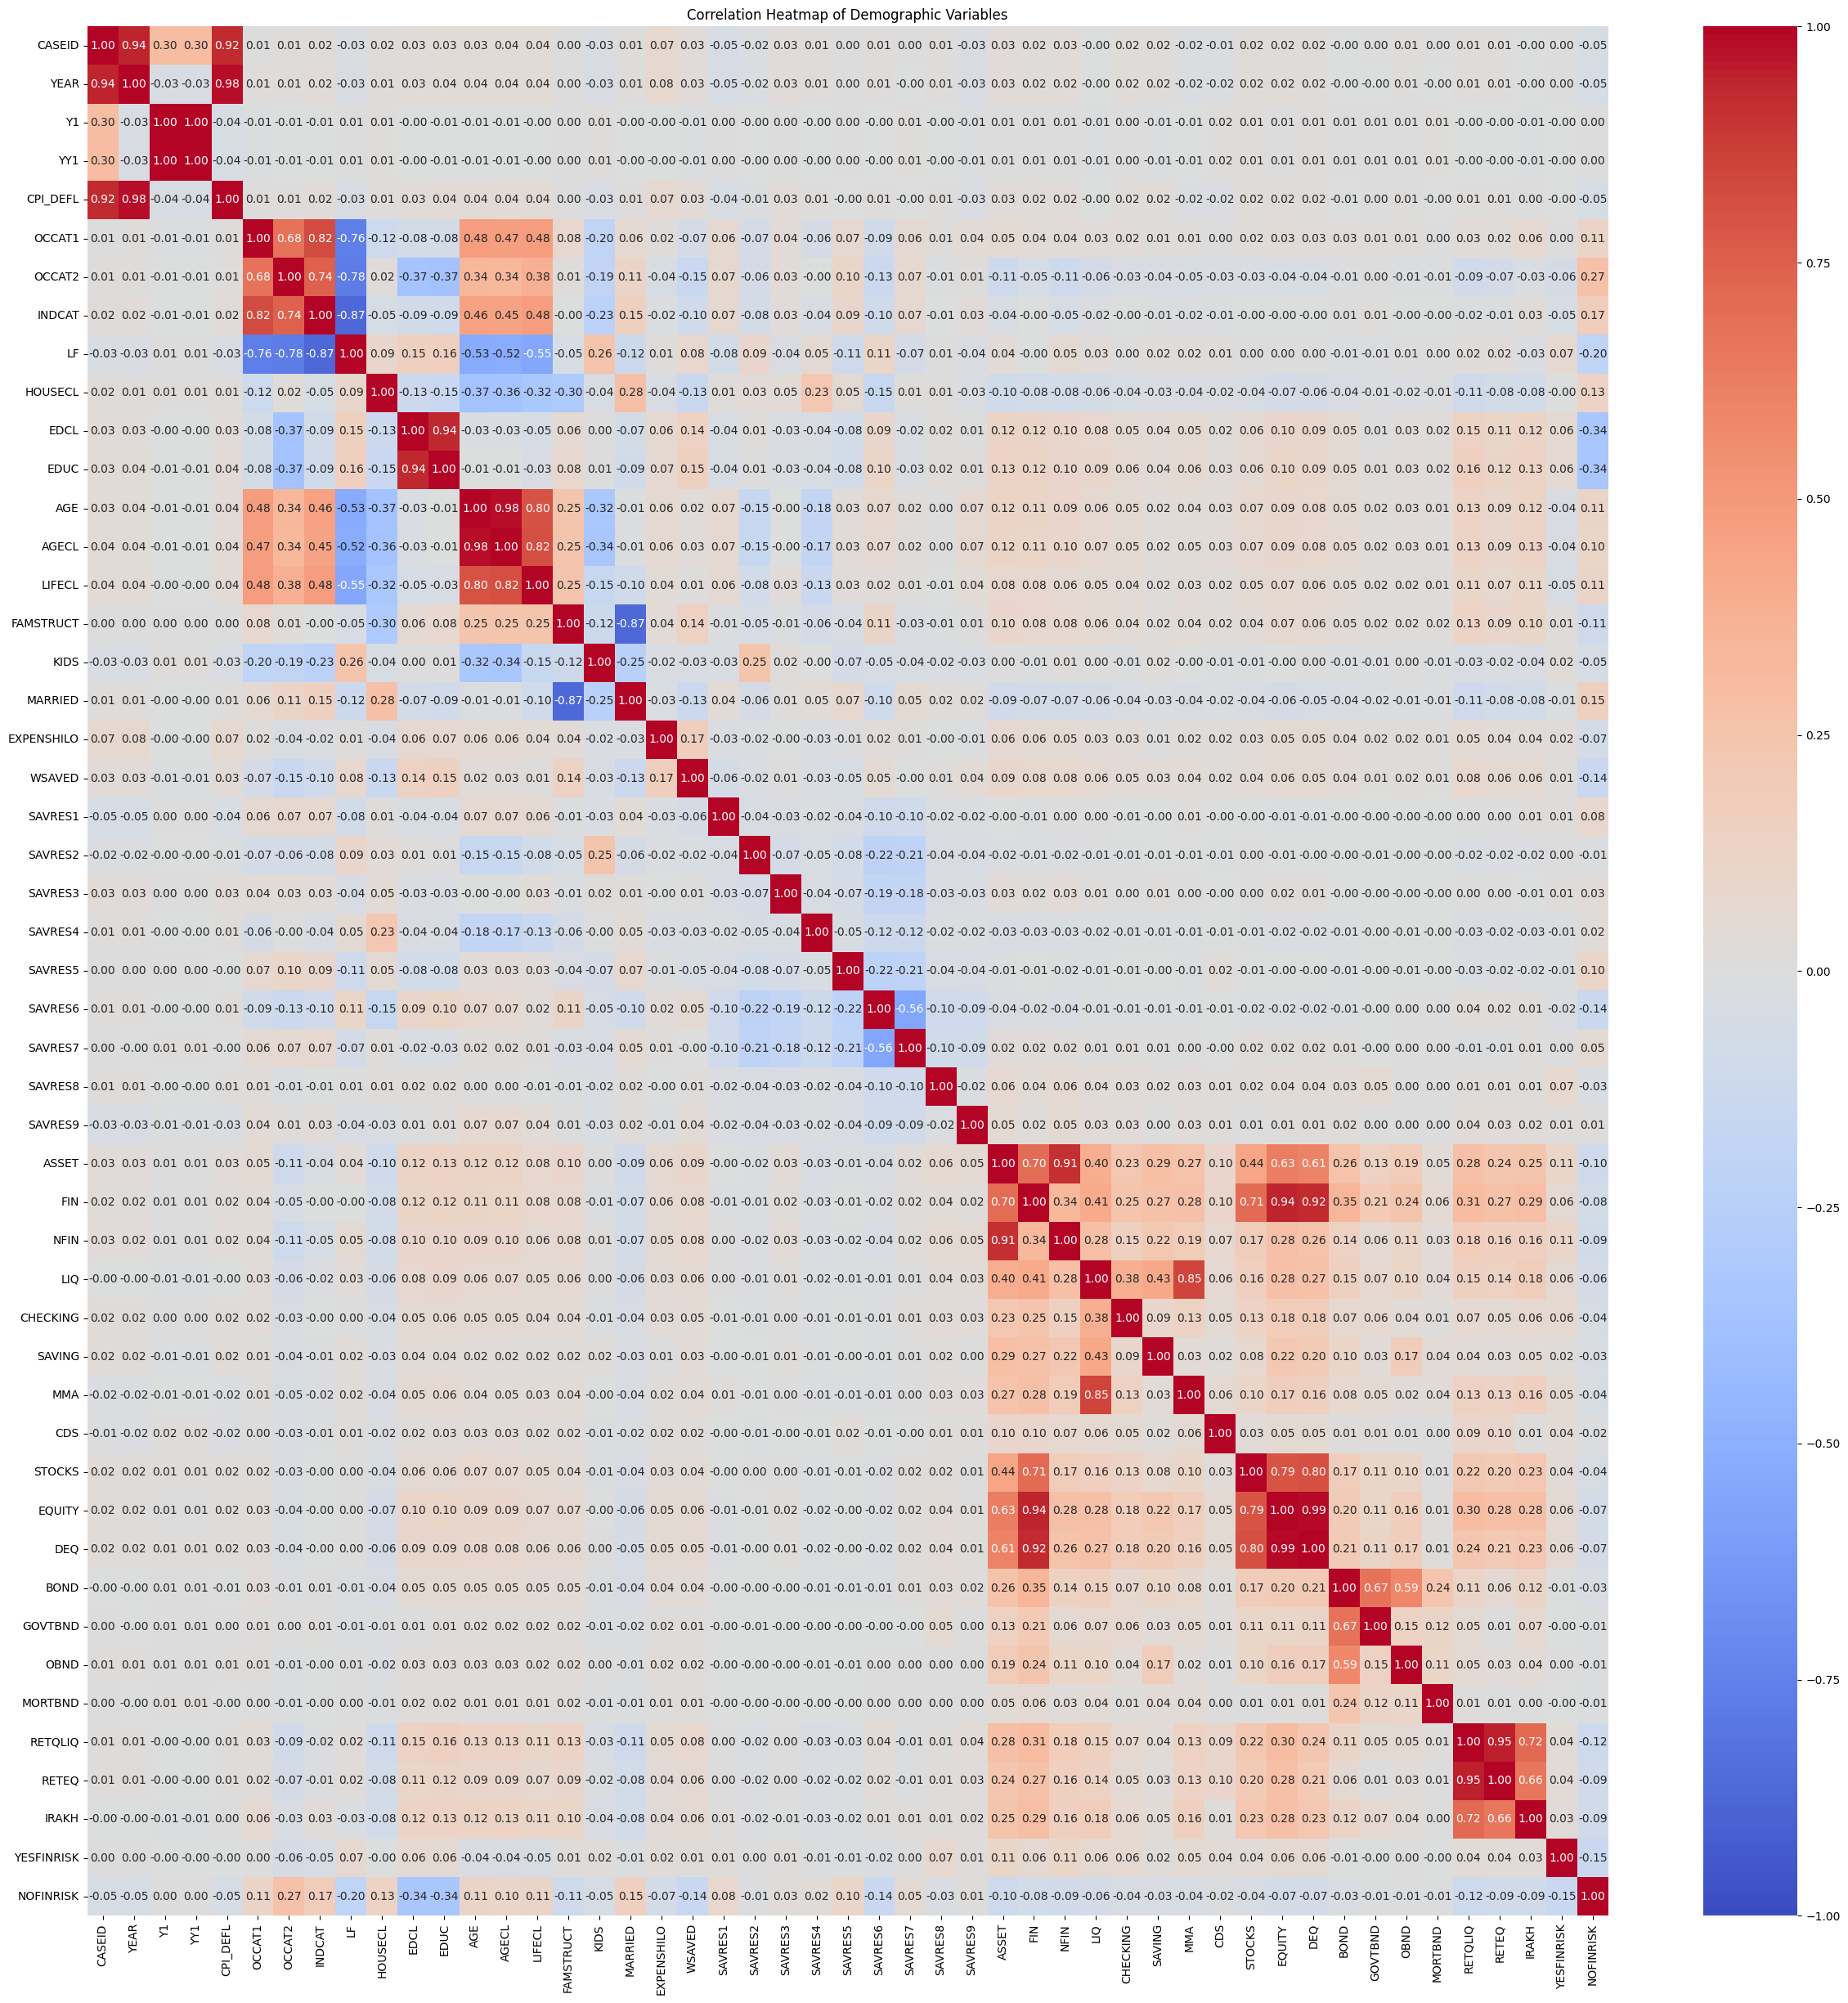

In [22]:
# 0. 데이터 숫자로 강제 변환: 공백 문자를 NaN으로 처리
df = df.apply(pd.to_numeric, errors='coerce')

# 1. 확인할 변수들만 선택
# cols_to_check = ['FAMSTRUCT', 'LIFECL']
# df = df[cols_to_check]
df_subset = df.iloc[2:]

# 2. 상관계수 행렬 계산
corr_matrix = df_subset.corr()

# 3. 히트맵 시각화
plt.figure(figsize=(30, 30))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Demographic Variables')
plt.show()

### VIF Visualization

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 0. 확인할 변수들만 선택
# cols_to_check = ['AGE', 'KIDS', 'FAMSTRUCT', 'LIFECL']
# df_subset = df_subset[cols_to_check]

# 1. 결측치가 있으면 VIF 계산이 안 되므로, 미리 처리하거나 제거(dropna)해야 합니다.
df_vif = df_subset.dropna()

# 2. 상수항 추가 (statsmodels에서 VIF를 계산할 때 일반적으로 상수항을 포함해야 정확합니다)
X = add_constant(df_vif)

# 3. VIF 계산을 위한 빈 데이터프레임 생성
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns

# 4. 각 피처별로 VIF 계산
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 5. 상수항(const) 행은 제외하고 출력
print(vif_data[vif_data['Feature'] != 'const'].sort_values(by='VIF', ascending=False))

c:\Users\User\Desktop\projects\life-to-fin-recsys\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\User\Desktop\projects\life-to-fin-recsys\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


       Feature           VIF
32        NFIN           inf
30       ASSET           inf
31         FIN           inf
26     SAVRES6  1.000800e+15
25     SAVRES5  3.002400e+14
27     SAVRES7  2.502000e+14
29     SAVRES9  2.047091e+14
22     SAVRES2  1.668000e+14
28     SAVRES8  1.047349e+14
23     SAVRES3  5.629500e+13
24     SAVRES4  3.532235e+13
21     SAVRES1  1.864845e+13
3           Y1  7.290616e+09
4          YY1  7.289867e+09
1       CASEID  4.308528e+05
2         YEAR  3.110008e+05
5     CPI_DEFL  4.812821e+03
39      EQUITY  6.946636e+01
40         DEQ  4.722361e+01
14       AGECL  2.574695e+01
13         AGE  2.369600e+01
33         LIQ  1.629808e+01
45     RETQLIQ  1.335276e+01
46       RETEQ  1.154514e+01
36         MMA  1.132981e+01
18     MARRIED  1.049747e+01
16   FAMSTRUCT  1.026020e+01
12        EDUC  8.349429e+00
11        EDCL  8.224995e+00
8       INDCAT  6.057450e+00
9           LF  5.899371e+00
41        BOND  4.074301e+00
15      LIFECL  3.558783e+00
6       OCCAT1